# Yelp Spark — Етап машинного навчання

Регресійна та класифікаційна моделі в PySpark ML на рівні **бізнесу** (150 346 записів).

| Вимога | Де виконано в зошиті |
| --- | --- |
| 1. Регресійна та класифікаційна модель у PySpark | розд. 3 (регресія `stars`), розд. 4 (класифікація `is_closed`) |
| 2. Попередня обробка даних | розд. 2 |
| 3. Мінімум 3 моделі для кожної задачі | по 4: Linear/LogisticRegression, DecisionTree, RandomForest, GBT |
| 4. Навчання та аналіз процесу навчання | розд. 3.1–3.2, 4.1–4.2 |
| 5. Метрики: RMSE, R²; Accuracy, Precision, Recall, F1 | розд. 3.3, 4.3 |
| 6. Порівняння алгоритмів | розд. 3.3, 4.3–4.4, 5 |

Повний звіт з висновками: [`src/reports/ml/README.md`](../reports/ml/README.md).
Той самий конвеєр без зошита: `uv run -m src.ml.run`. Повне виконання займає ~37 хв на 8 ядрах.

## 1. Налаштування

In [1]:
import os
import sys
import time
from pathlib import Path

# Make sure project root is on sys.path when running the notebook directly
project_root = Path("__file__").resolve().parent.parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Use every core for training (src.spark.session reads this variable).
os.environ.setdefault("SPARK_MAX_CORES", str(os.cpu_count()))

import pandas as pd
from IPython.display import Image, display
from pyspark.sql import functions as F

from src.constants import ML_REPORT_DIR, ML_RESULTS_DIR
from src.ml import features as ft
from src.ml import plots, report
from src.ml.training import (
    configure_spark_for_training,
    release,
    run_classification,
    run_regression,
)
from src.spark.load_data import load_dataset
from src.spark.session import create_spark_session

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

FIG = ML_REPORT_DIR / "figures"
TABLES = ML_REPORT_DIR / "tables"
started = time.perf_counter()

spark = create_spark_session("yelp-ml-notebook")
spark.sparkContext.setLogLevel("ERROR")
configure_spark_for_training(spark)
print("Spark", spark.version, "| cores:", spark.sparkContext.defaultParallelism)


def show(path):
    display(Image(filename=str(path)))

Picked up JAVA_TOOL_OPTIONS: -XX:+IgnoreUnrecognizedVMOptions -Xmx8g -XX:+UseG1GC -XX:-UseContainerSupport
Picked up JAVA_TOOL_OPTIONS: -XX:+IgnoreUnrecognizedVMOptions -Xmx8g -XX:+UseG1GC -XX:-UseContainerSupport


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/10/03 13:54:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.1.1 | cores: 8


## 2. Попередня обробка даних

**Одиниця аналізу — бізнес.** Таблиця ознак будується з `business` та агрегатів `review`, `tip`, `checkin`, `photo`
(`src/ml/features.py`), один раз зберігається у Parquet (`artifacts/processed/ml/business_features`).

Перетворення, які **не навчаються на даних** (виконуються для всіх рядків):

* розбір `attributes` (рядки у форматі Python: `u'free'`, `'none'`, `None`, вкладені словники `{'casual': True, ...}`)
  → булеві атрибути у кодуванні `1 / -1 / 0` (так / ні / невідомо), категоріальні (`wifi`, `noise_level`, `alcohol`, `attire`)
  з рівнем `missing`, `price_range`;
* `hours` → кількість робочих днів, годин на тиждень, відкрито у вихідні / пізно / рано; `0:0-0:0` (неоднозначне значення) — окремий прапорець;
* `categories` → масив категорій; штати з < 100 бізнесів → `OTHER`;
* агрегати відгуків **без оцінок** (середні `useful/funny/cool`, довжина тексту, «вік» бізнесу), порад, відвідувань, фото;
* логарифмування лічильників з важкими хвостами (`log1p`).

Перетворення, які **навчаються** (Spark ML `Pipeline`, `fit` лише на тренувальній вибірці):
`Imputer(median)` → `StringIndexer` + `OneHotEncoder` → `CountVectorizer` (60 найчастіших категорій) → `VectorAssembler` → `StandardScaler`.

**Захист від витоку цільової змінної:** жодних агрегатів `review.stars` чи `user.average_stars` (рейтинг бізнесу —
це округлене середнє оцінок відгуків) і жодних ознак зі *змісту* тексту (слова, тональність ≈ оцінка). Використовуються
лише середня довжина тексту та середні голоси `useful/funny/cool` тих самих відгуків — вони корелюють з тональністю,
тому в розд. 3.3 наведено абляцію лише з ознаками профілю бізнесу як нижню межу без них. Командний ETL
(`src/preprocessing`) не використовується, бо масштабує ознаки по всьому набору (витік статистик тесту) і залишає
сирі рядки атрибутів.

In [2]:
# Before/after: raw attribute strings -> parsed columns
raw = load_dataset(spark, "business")
example = raw.filter(
    F.col("attributes")["Ambience"].isNotNull() & F.col("attributes")["Alcohol"].isNotNull()
).limit(3)
example.select(
    "name",
    F.col("attributes")["WiFi"].alias("WiFi_raw"),
    F.col("attributes")["Alcohol"].alias("Alcohol_raw"),
    F.col("attributes")["Ambience"].alias("Ambience_raw"),
    F.col("hours")["Friday"].alias("Friday_raw"),
).show(truncate=70)
parsed = ft.parse_hours(ft.parse_attributes(example))
parsed.select(
    "name", "wifi", "alcohol", "ambience_casual", "ambience_classy",
    "price_range", "weekly_open_hours", "open_late",
).show()

+---------------------+--------+-----------+----------------------------------------------------------------------+----------+
|                 name|WiFi_raw|Alcohol_raw|                                                          Ambience_raw|Friday_raw|
+---------------------+--------+-----------+----------------------------------------------------------------------+----------+
|       Sonic Drive-In|   u'no'|    u'none'|                                                                  None|   9:0-0:0|
|Tsevi's Pub And Grill| u'free'|u'full_bar'|{'romantic': False, 'intimate': False, 'touristy': False, 'hipster'...|      NULL|
|Vietnamese Food Truck|    NULL|     'none'|{'touristy': False, 'hipster': False, 'romantic': False, 'divey': F...| 11:0-14:0|
+---------------------+--------+-----------+----------------------------------------------------------------------+----------+



+--------------------+-------+--------+---------------+---------------+-----------+-----------------+---------+
|                name|   wifi| alcohol|ambience_casual|ambience_classy|price_range|weekly_open_hours|open_late|
+--------------------+-------+--------+---------------+---------------+-----------+-----------------+---------+
|      Sonic Drive-In|     no|    none|            0.0|            0.0|        1.0|             90.0|      1.0|
|Tsevi's Pub And G...|   free|full_bar|           -1.0|           -1.0|        1.0|              0.0|      0.0|
|Vietnamese Food T...|missing|    none|           -1.0|           -1.0|       NULL|             23.0|      0.0|
+--------------------+-------+--------+---------------+---------------+-----------+-----------------+---------+



In [3]:
features = ft.load_or_build_features(spark).cache()
print(f"Feature table: {features.count():,} businesses x {len(features.columns)} columns")

numeric = [c for c, t in features.dtypes if t == "double" and c not in ("stars", "is_closed")]
nulls = features.select(
    [F.avg(F.col(c).isNull().cast("double")).alias(c) for c in numeric]
).first().asDict()
missing_levels = features.select(
    [F.avg((F.col(c) == "missing").cast("double")).alias(c) for c in ft.CATEGORICAL_ATTRIBUTES.values()]
).first().asDict()
quality = pd.DataFrame(
    [{"feature": k, "share_null_or_missing": v} for k, v in {**nulls, **missing_levels}.items() if v]
).sort_values("share_null_or_missing", ascending=False)
print("Features with missing values before imputation:")
display(quality)

Feature table: 150,346 businesses x 78 columns


Features with missing values before imputation:


,feature,share_null_or_missing
2,noise_level,0.747556
4,attire,0.739155
3,alcohol,0.712989
1,wifi,0.621779
0,price_range,0.432775


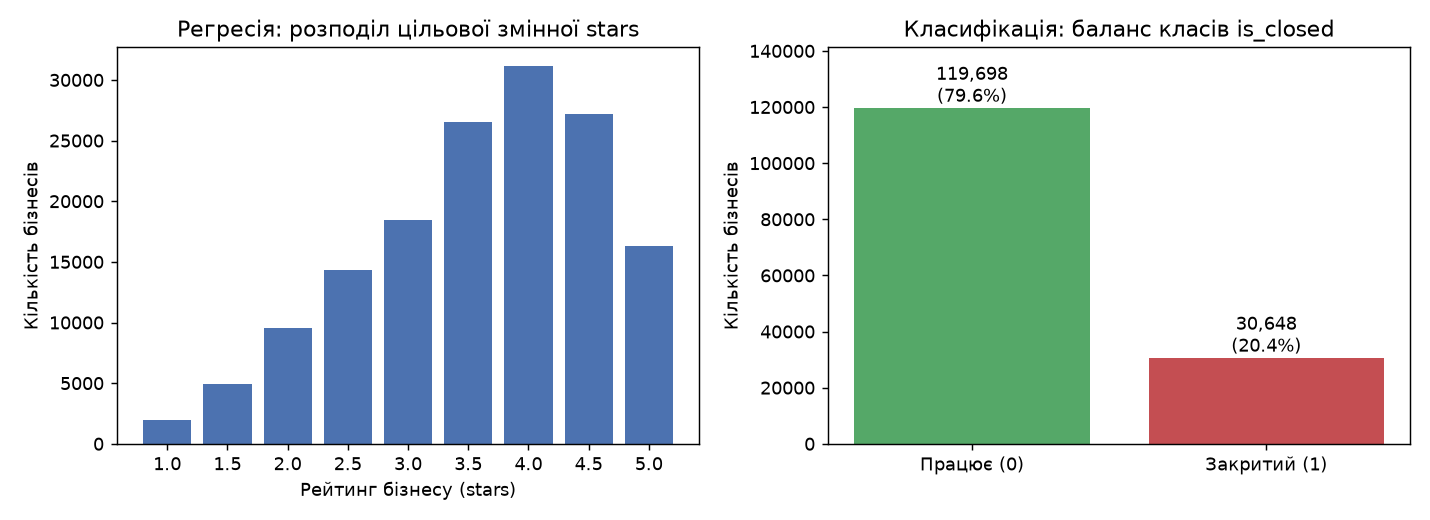

In [4]:
target_sample = features.select("stars", "is_closed").toPandas()
show(plots.target_distributions(target_sample, FIG / "target_distributions.png"))

**Розбиття.** Детерміноване за хешем `business_id` (`xxhash64 mod 100`): 70% train / 15% validation / 15% test,
однакове для обох задач і всіх запусків. Гіперпараметри обираються на validation, тест оцінюється **один раз**
моделлю, навченою лише на train (без донавчання на train+validation).

## 3. Регресія: прогноз рейтингу бізнесу `stars`

Моделі: `LinearRegression` (еластична сітка, L-BFGS), `DecisionTreeRegressor`, `RandomForestRegressor`, `GBTRegressor`.
Базові рівні: середнє train та середнє за (штат × перша категорія). Критерій вибору — RMSE на validation.
Прогнози обрізаються до діапазону [1; 5].

In [5]:
regression = run_regression(features)

[13:54:19] Task regression: preparing data


[13:54:26] Task regression: 167 features, train/val/test = 105191/22654/22501


[13:54:26] Task regression: tuning LinearRegression (9 settings)


[13:54:32]   LinearRegression {'regParam': 0.0005, 'elasticNetParam': 0.0} fit 4.4s train rmse=0.7811 val rmse=0.7759


[13:54:38]   LinearRegression {'regParam': 0.0005, 'elasticNetParam': 0.5} fit 6.2s train rmse=0.7812 val rmse=0.7760


...

[14:07:27]   learning curve 10% (10703 rows) done


[14:08:09]   learning curve 24% (25825 rows) done


[14:09:01]   learning curve 50% (52930 rows) done


[14:10:07]   learning curve 100% (105191 rows) done


[14:10:11] Ablation: profile-only features


In [6]:
print("Fitted preprocessing PipelineModel stages:")
for i, stage in enumerate(regression.data.preprocessing.stages, 1):
    print(f"  {i}. {stage}")
print("Feature vector size:", len(regression.data.feature_names))
reg_tables = report.write_task(regression, TABLES)
display(reg_tables["splits"])

Fitted preprocessing PipelineModel stages:
  1. ImputerModel: uid=Imputer_ad5268d12061, strategy=median, missingValue=NaN, numInputCols=70, numOutputCols=70
  2. StringIndexerModel: uid=StringIndexer_3432d1358c3a, handleInvalid=keep, stringOrderType=frequencyDesc, numInputCols=5, numOutputCols=5
  3. OneHotEncoderModel: uid=OneHotEncoder_fa2bd62ff15f, dropLast=true, handleInvalid=keep, numInputCols=5, numOutputCols=5
  4. CountVectorizerModel: uid=CountVectorizer_e9c8a9347562, vocabularySize=60
  5. VectorAssembler_361cba66b904
  6. StandardScalerModel: uid=StandardScaler_1ac95084eb3e, numFeatures=167, withMean=false, withStd=true
Feature vector size: 167


,split,rows,mean_stars
0,train,105191,3.594576
1,validation,22654,3.603999
2,test,22501,3.599440


### 3.1 Підбір гіперпараметрів (усі спроби: train / validation, час навчання)

In [7]:
display(reg_tables["tuning"])

,model,params,fit_seconds,search_seconds,train_rmse,val_rmse,train_r2,val_r2
0,LinearRegression,"{""regParam"": 0.0005, ""elasticNetParam"": 0.0}",4.35,4.35,0.781102,0.775904,0.359162,0.359748
1,LinearRegression,"{""regParam"": 0.0005, ""elasticNetParam"": 0.5}",6.17,6.17,0.781182,0.775991,0.359031,0.359604
2,LinearRegression,"{""regParam"": 0.0005, ""elasticNetParam"": 1.0}",8.40,8.40,0.781265,0.776067,0.358894,0.359479
3,LinearRegression,"{""regParam"": 0.005, ""elasticNetParam"": 0.0}",1.59,1.59,0.781467,0.776266,0.358563,0.359150
4,LinearRegression,"{""regParam"": 0.005, ""elasticNetParam"": 0.5}",9.09,9.09,0.783001,0.777643,0.356043,0.356875
5,LinearRegression,"{""regParam"": 0.005, ""elasticNetParam"": 1.0}",3.79,3.79,0.785528,0.780058,0.351880,0.352874
6,LinearRegression,"{""regParam"": 0.05, ""elasticNetParam"": 0.0}",1.31,1.31,0.785675,0.780323,0.351637,0.352434
7,LinearRegression,"{""regParam"": 0.05, ""elasticNetParam"": 0.5}",1.55,1.55,0.818971,0.813654,0.295519,0.295932
8,LinearRegression,"{""regParam"": 0.05, ""elasticNetParam"": 1.0}",1.00,1.00,0.852732,0.847973,0.236239,0.235285
9,DecisionTreeRegressor,"{""maxDepth"": 2, ""minInstancesPerNode"": 1}",0.74,0.74,0.923901,0.918854,0.103433,0.102099


### 3.2 Аналіз процесу навчання

* збіжність оптимізатора лінійної регресії та вплив регуляризації;
* дерево рішень: недонавчання → перенавчання зі зростанням глибини;
* випадковий ліс: кількість і глибина дерев;
* GBT: RMSE на train і validation після кожної ітерації бустингу (обирається найкраща ітерація);
* крива навчання найкращої моделі та час навчання.

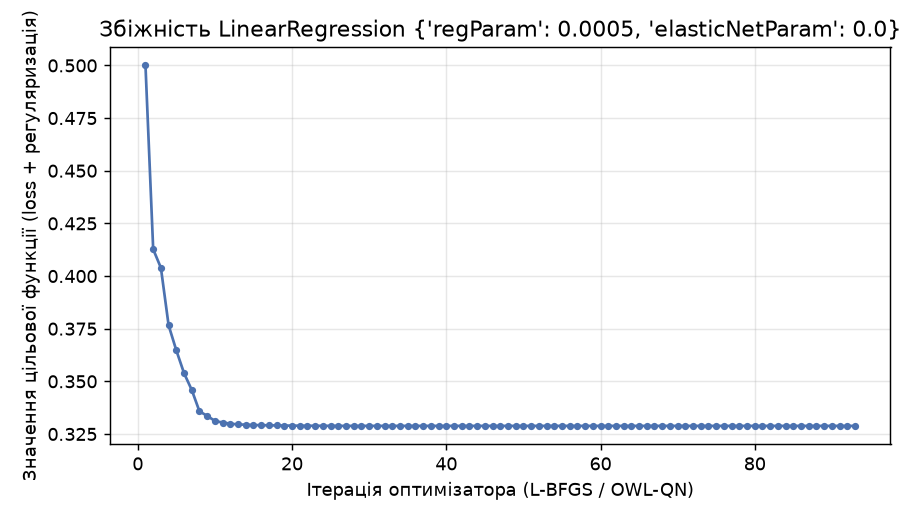

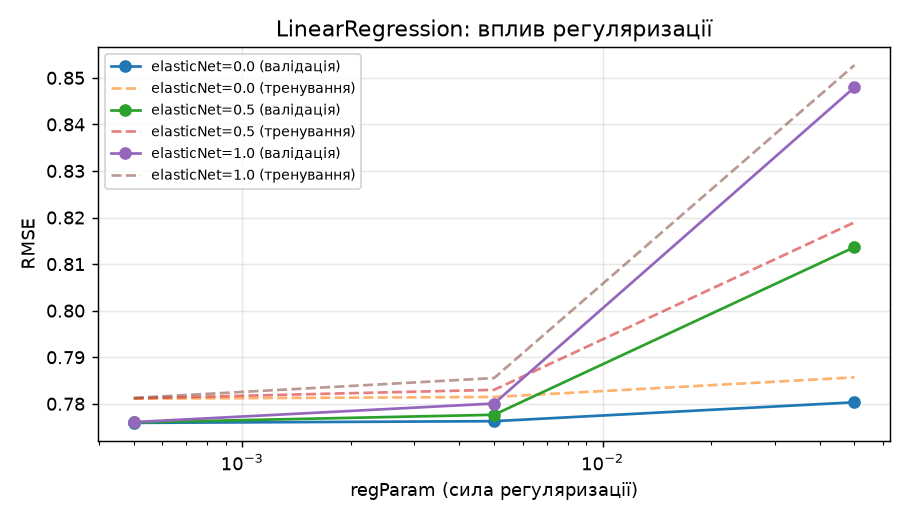

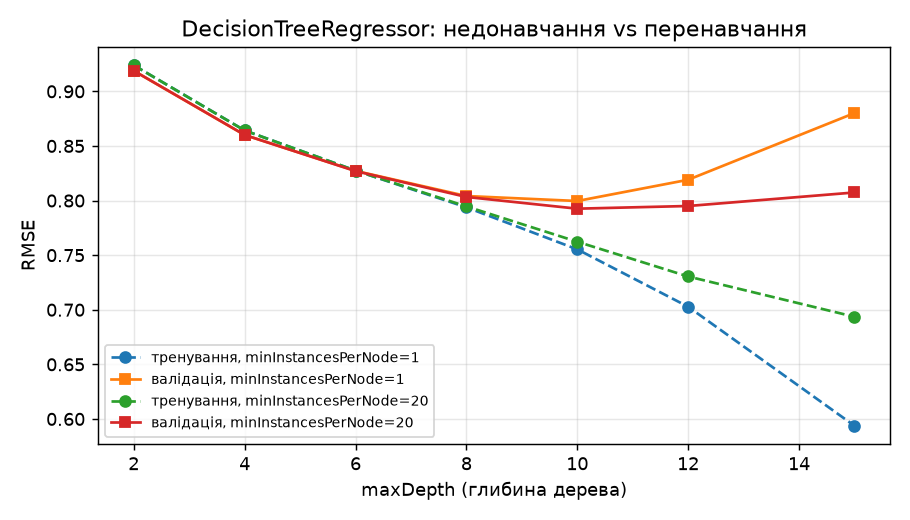

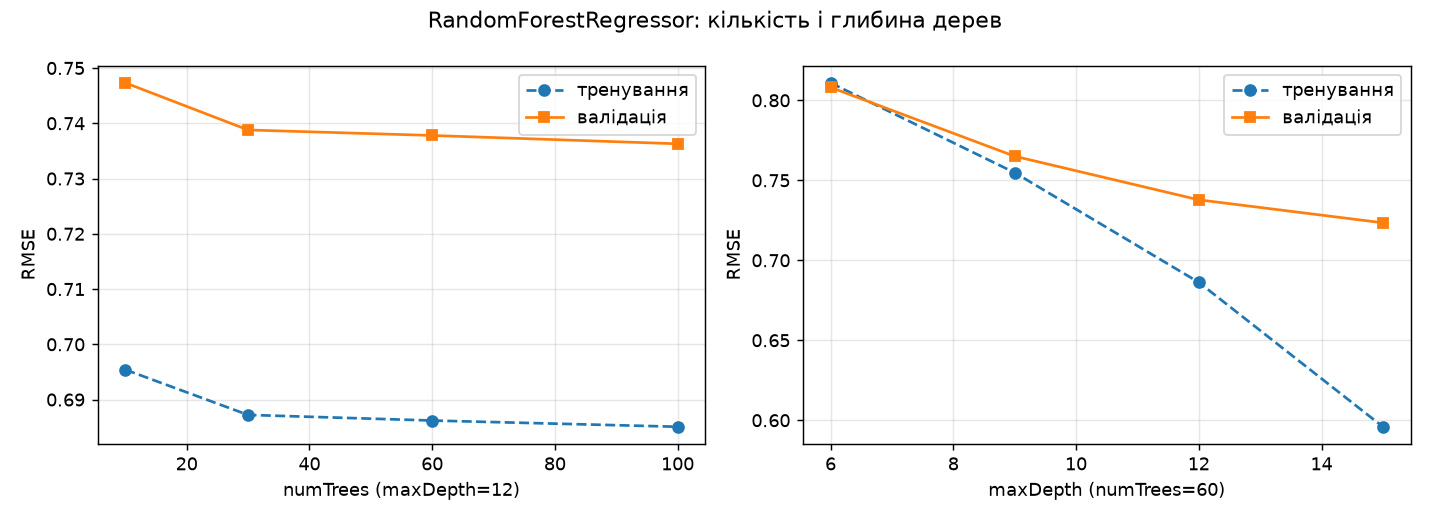

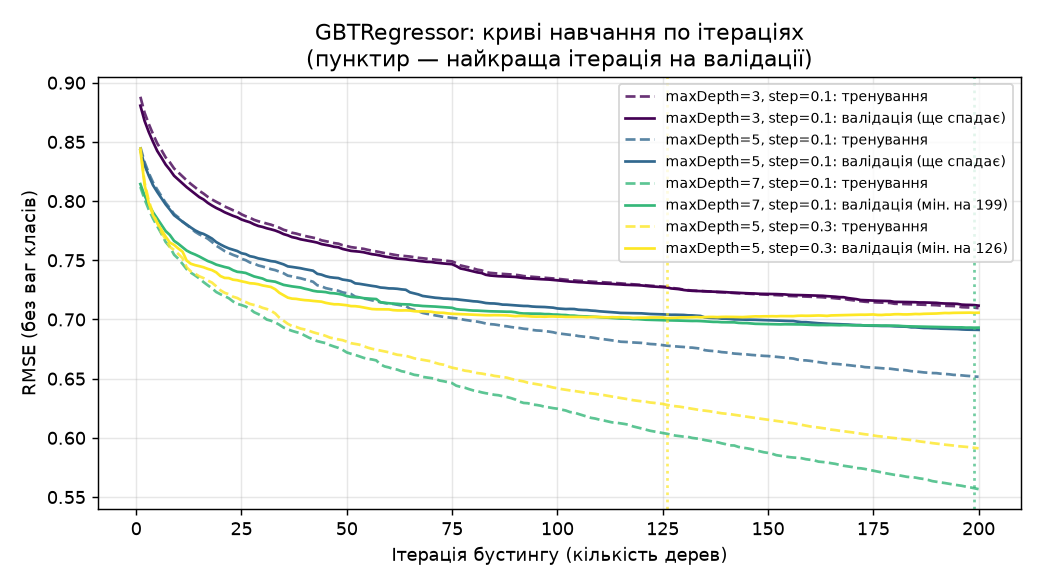

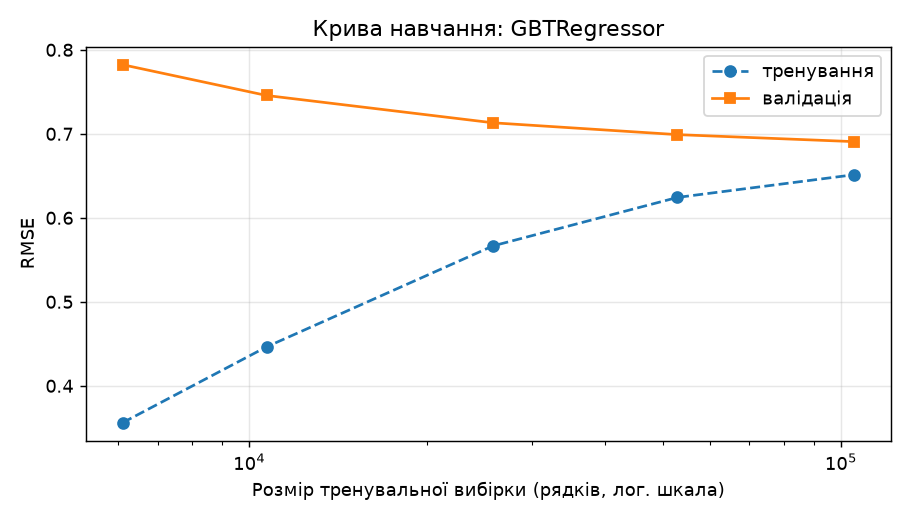

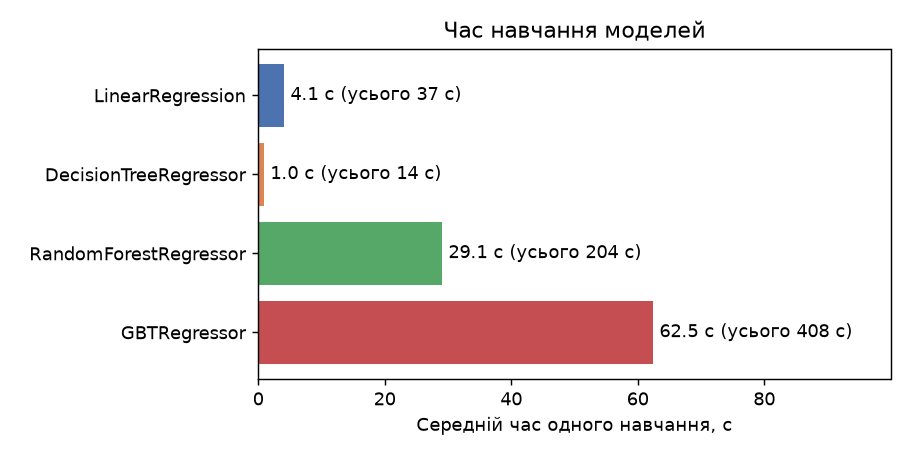

,train_fraction,train_rows,fit_seconds,train_rmse,train_r2,train_mae,train_within_half_star,val_rmse,val_r2,val_mae,val_within_half_star
0,0.057143,6109,32.30,0.356085,0.866865,0.268667,0.855950,0.782286,0.349171,0.602516,0.519114
1,0.100000,10703,34.96,0.446450,0.791656,0.343505,0.767262,0.745617,0.408756,0.574396,0.535799
2,0.242857,25825,40.92,0.566570,0.663092,0.436209,0.656302,0.713118,0.459174,0.549883,0.553545
3,0.500000,52930,50.66,0.624278,0.593250,0.480278,0.614566,0.699036,0.480323,0.539239,0.561225
4,1.000000,105191,64.70,0.651277,0.554484,0.500863,0.596686,0.690704,0.492637,0.531786,0.568685


In [8]:
for path in [
    plots.convergence(regression, FIG / "reg_linear_convergence.png"),
    plots.regularization_path(regression, "rmse", FIG / "reg_linear_regularization.png"),
    plots.tree_depth_curve(regression, "rmse", FIG / "reg_tree_depth.png"),
    plots.forest_curves(regression, "rmse", FIG / "reg_forest.png"),
    plots.gbt_iterations(regression, FIG / "reg_gbt_iterations.png"),
    plots.learning_curve(regression, "rmse", FIG / "reg_learning_curve.png"),
    plots.fit_times(regression, FIG / "reg_fit_times.png"),
]:
    show(path)
display(reg_tables["learning_curve"])

### 3.3 Якість моделей: RMSE, R² (тест, 95% bootstrap-інтервали) та порівняння

,model,rmse,r2,mae,within_half_star,rmse_95ci,r2_95ci,fit_seconds,best_params
0,Baseline: train mean,0.972953,-0.000025,0.796013,0.384561,NaN,NaN,NaN,NaN
1,Baseline: mean by state x category,0.920905,0.104105,0.744170,0.394471,NaN,NaN,NaN,NaN
2,LinearRegression,0.775721,0.364320,0.609962,0.496022,[0.768; 0.783],[0.355; 0.373],4.4,"{""regParam"": 0.0005, ""elasticNetParam"": 0.0}"
3,DecisionTreeRegressor,0.788463,0.343265,0.613600,0.508333,[0.781; 0.797],[0.331; 0.355],1.0,"{""maxDepth"": 10, ""minInstancesPerNode"": 20}"
4,RandomForestRegressor,0.721801,0.449620,0.565414,0.529888,[0.715; 0.730],[0.440; 0.458],84.8,"{""numTrees"": 60, ""maxDepth"": 15}"
5,GBTRegressor,0.685968,0.502910,0.526896,0.576997,[0.679; 0.693],[0.493; 0.512],68.4,"{""maxDepth"": 5, ""stepSize"": 0.1, ""maxIter"": 200}"


,model,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,LinearRegression,0.781102,0.775904,0.775721,0.359162,0.359748,0.364320
1,DecisionTreeRegressor,0.762294,0.792557,0.788463,0.389651,0.331969,0.343265
2,RandomForestRegressor,0.595926,0.723442,0.721801,0.626993,0.443400,0.449620
3,GBTRegressor,0.651277,0.690704,0.685968,0.554484,0.492637,0.502910


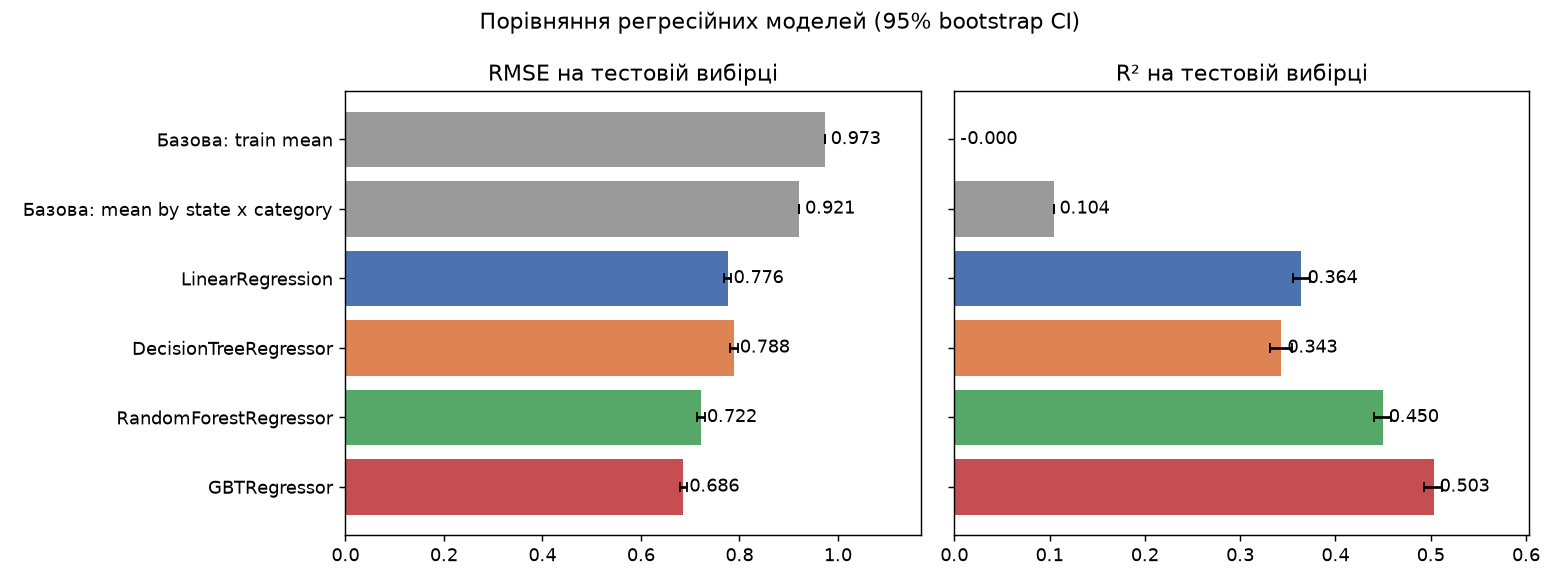

Paired bootstrap, top-2 models: {'a': 'GBTRegressor', 'b': 'RandomForestRegressor', 'metric': 'rmse', 'diff': -0.0358336223103497, 'ci_low': -0.039409082114815724, 'ci_high': -0.0320757129204945, 'share_a_better': 1.0}
Ablation, profile-only features: {'model': 'GBTRegressor', 'params': {'maxDepth': 5, 'stepSize': 0.1, 'maxIter': 200}, 'n_features': 148, 'fit_seconds': 64.77140545899965, 'validation': {'rmse': 0.7928530617800831, 'r2': 0.33147049324013855, 'mae': 0.6218171508207473, 'within_half_star': 0.49187781407257}, 'test': {'rmse': 0.7891311714471884, 'r2': 0.3421518599767224, 'mae': 0.617286519363843, 'within_half_star': 0.4941558152970979}}


In [9]:
display(reg_tables["comparison"])
display(reg_tables["generalisation"])
show(plots.regression_comparison(regression, FIG / "reg_comparison.png"))
print("Paired bootstrap, top-2 models:", regression.extras["top_two"])
print("Ablation, profile-only features:", regression.extras["profile_only"])

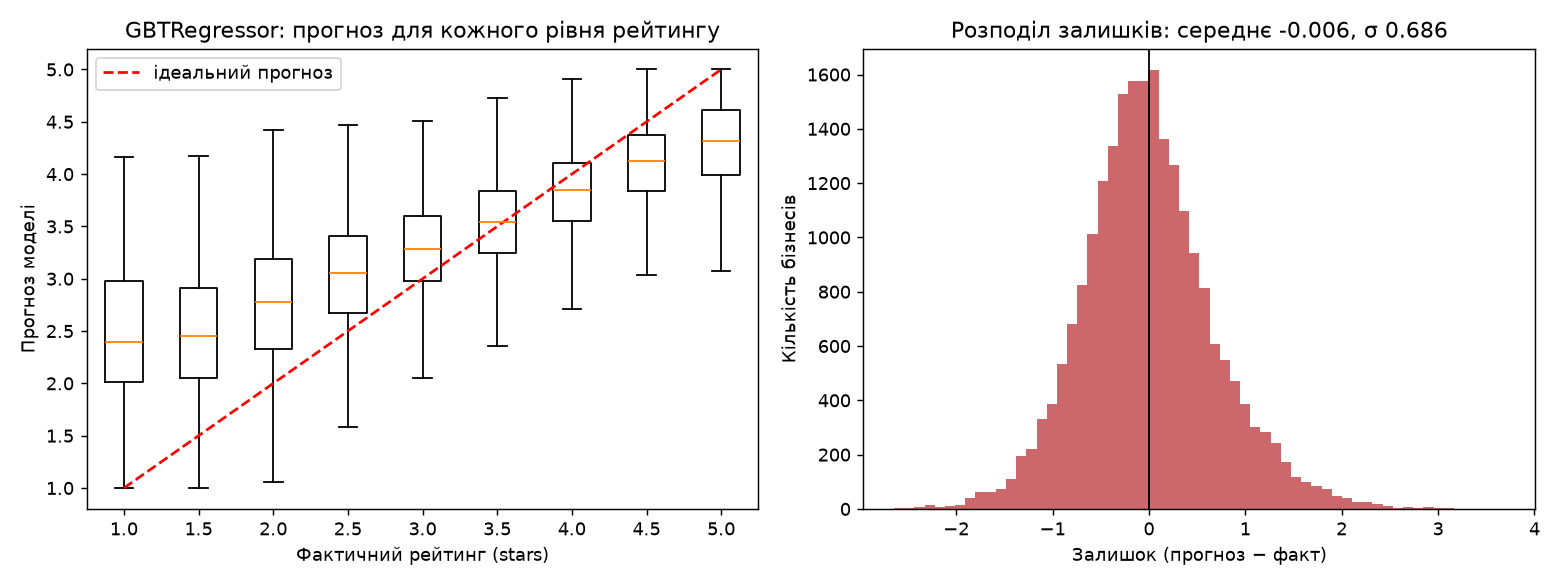

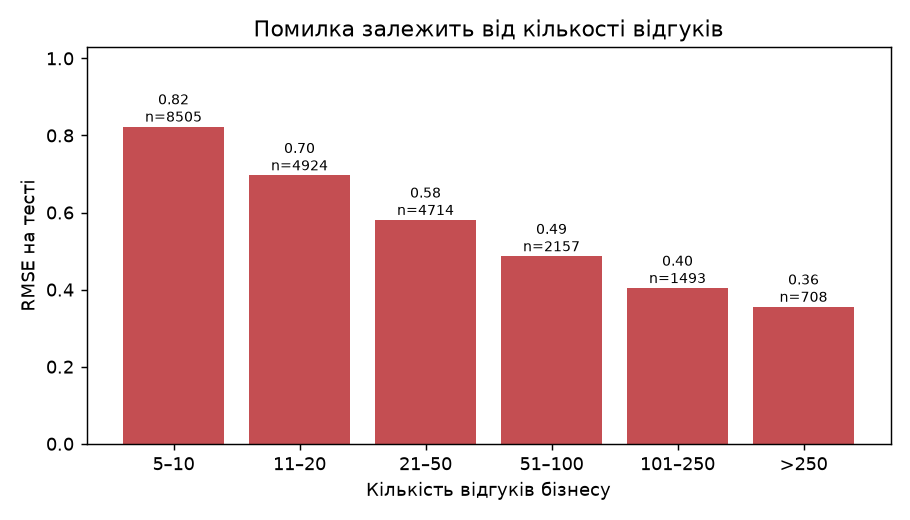

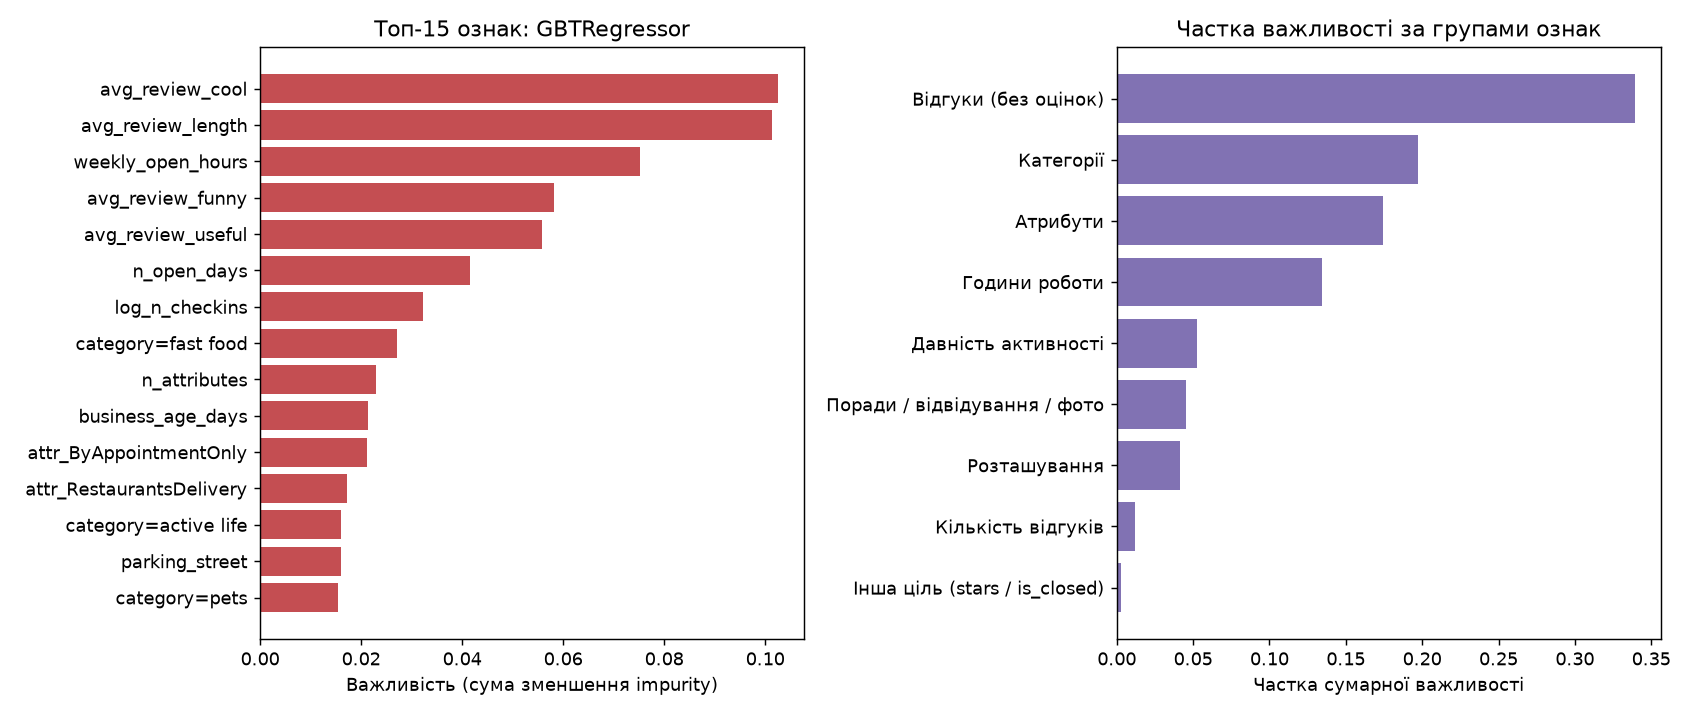

In [10]:
for path in [
    plots.predictions_by_star(regression, FIG / "reg_predictions_by_star.png"),
    plots.error_by_review_count(regression, FIG / "reg_error_by_review_count.png"),
    plots.feature_importance(regression, FIG / "reg_feature_importance.png"),
]:
    show(path)
release(regression.data)

## 4. Класифікація: виявлення закритих бізнесів `is_closed`

Позитивний клас — **закритий бізнес** (≈20%). Precision / Recall / F1 рахуються саме для нього
(стандартний `MulticlassClassificationEvaluator` за замовчуванням звітує клас 0 і зважений F1, тому всі метрики
обчислюються з матриці помилок). Дисбаланс компенсується вагами класів `w_c = N / (2·n_c)` (лише при навчанні).
Критерій вибору гіперпараметрів — PR-AUC на validation (не залежить від порогу); порівняння — при порозі 0.5.

Основний варіант — **без ознак давності активності** (`days_since_last_*`, частка активності за останній рік):
закритий бізнес перестає отримувати відгуки, тож ці ознаки є переважно *наслідком* закриття. Варіант з ними
(розд. 4.4) розв'язує задачу «виявлення застарілих карток» і показує, наскільки вони домінують.
Навіть без них частина ознак профілю непрямо відображає «свіжість» картки (новіші атрибути на кшталт `DriveThru`,
формат годин `0:0-0:0`, кількість заповнених атрибутів): закриті бізнеси перестають оновлювати картку. Це обмеження
описано у звіті.

In [11]:
classification = run_classification(features, include_recency=False)
cls_tables = report.write_task(classification, TABLES)
display(cls_tables["splits"])

[14:11:25] Task classification: preparing data


[14:11:34] Task classification: 162 features, train/val/test = 105191/22654/22501


[14:11:34] Task classification: tuning LogisticRegression (9 settings)


[14:11:40]   LogisticRegression {'regParam': 0.0005, 'elasticNetParam': 0.0} fit 3.4s train pr_auc=0.6181 val pr_auc=0.6244


[14:11:52]   LogisticRegression {'regParam': 0.0005, 'elasticNetParam': 0.5} fit 10.0s train pr_auc=0.6176 val pr_auc=0.6241


...

[14:23:52]   learning curve 24% (25825 rows) done


[14:25:08]   learning curve 50% (52930 rows) done


[14:26:43]   learning curve 100% (105191 rows) done


[14:26:48] Class weights vs. threshold comparison


,split,rows,mean_is_closed
0,train,105191,0.204656
1,validation,22654,0.199391
2,test,22501,0.204569


### 4.1 Підбір гіперпараметрів

In [12]:
display(cls_tables["tuning"])

,model,params,fit_seconds,search_seconds,train_f1,val_f1,train_pr_auc,val_pr_auc
0,LogisticRegression,"{""regParam"": 0.0005, ""elasticNetParam"": 0.0}",3.41,3.41,0.542176,0.545637,0.618100,0.624379
1,LogisticRegression,"{""regParam"": 0.0005, ""elasticNetParam"": 0.5}",10.03,10.03,0.542058,0.545668,0.617631,0.624052
2,LogisticRegression,"{""regParam"": 0.0005, ""elasticNetParam"": 1.0}",6.49,6.49,0.541692,0.544936,0.617117,0.623638
3,LogisticRegression,"{""regParam"": 0.005, ""elasticNetParam"": 0.0}",1.86,1.86,0.542420,0.545714,0.616444,0.622903
4,LogisticRegression,"{""regParam"": 0.005, ""elasticNetParam"": 0.5}",2.53,2.53,0.540000,0.543411,0.608707,0.616002
5,LogisticRegression,"{""regParam"": 0.005, ""elasticNetParam"": 1.0}",2.39,2.39,0.536387,0.541198,0.601645,0.609315
6,LogisticRegression,"{""regParam"": 0.05, ""elasticNetParam"": 0.0}",1.24,1.24,0.537218,0.538156,0.603893,0.610745
7,LogisticRegression,"{""regParam"": 0.05, ""elasticNetParam"": 0.5}",2.02,2.02,0.502388,0.508495,0.535651,0.549270
8,LogisticRegression,"{""regParam"": 0.05, ""elasticNetParam"": 1.0}",2.19,2.19,0.471261,0.479211,0.457440,0.468851
9,DecisionTreeClassifier,"{""maxDepth"": 2, ""minInstancesPerNode"": 1}",0.63,0.63,0.417311,0.420678,0.328481,0.327568


### 4.2 Аналіз процесу навчання

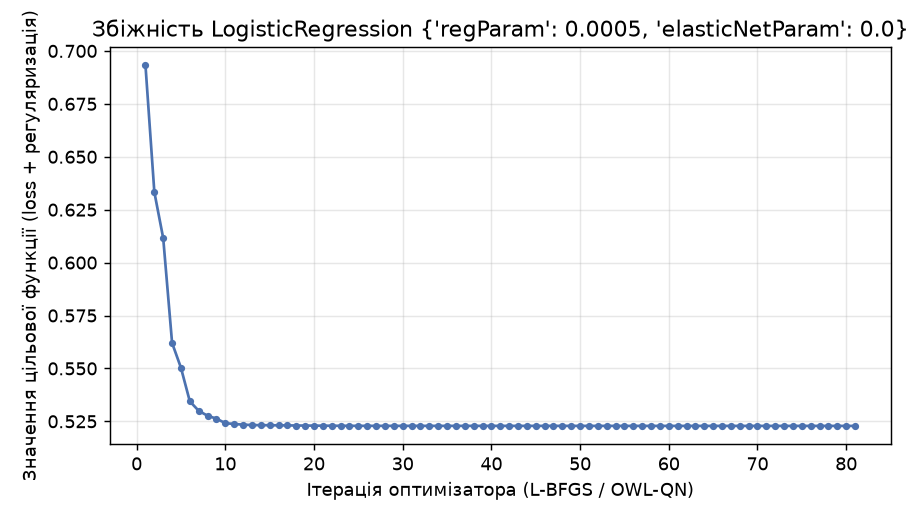

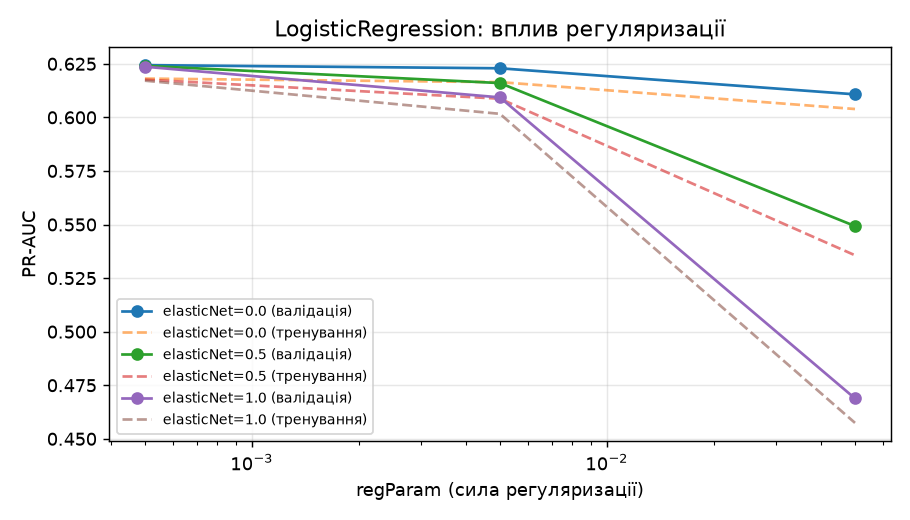

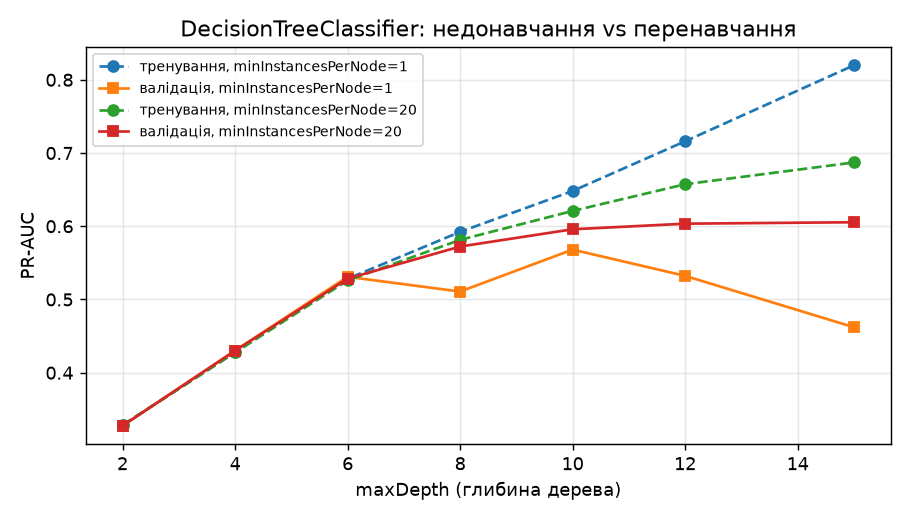

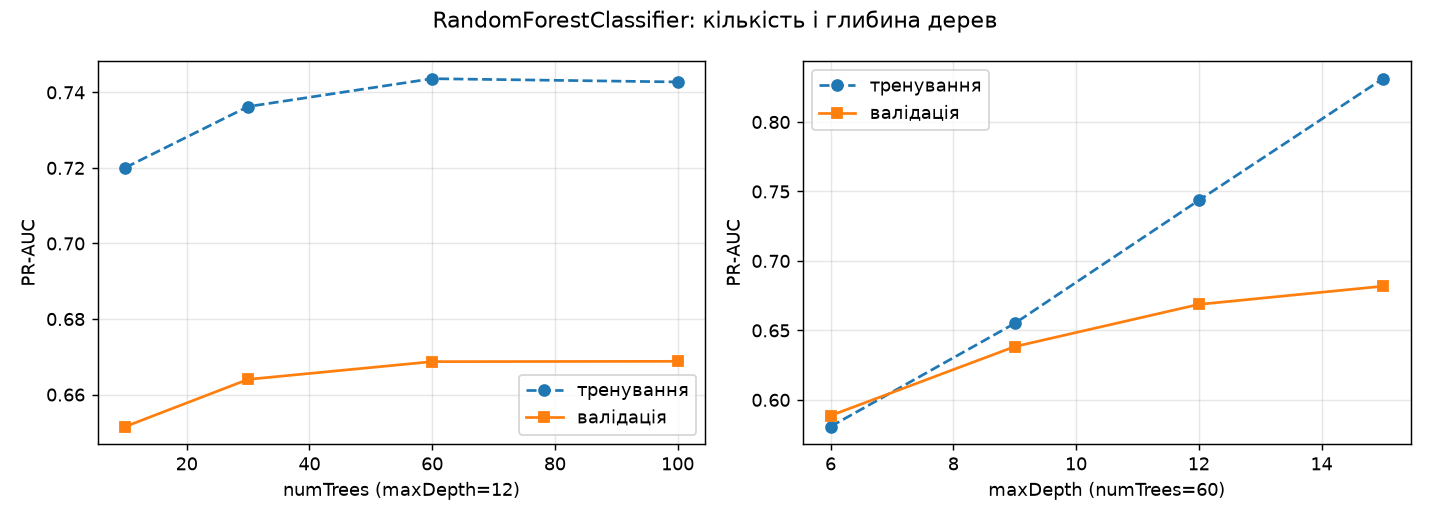

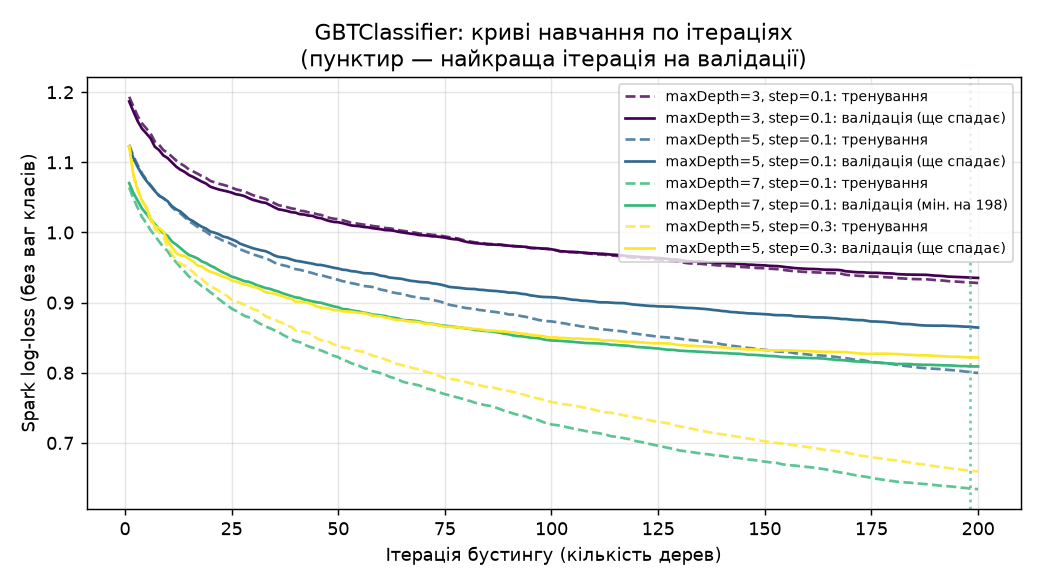

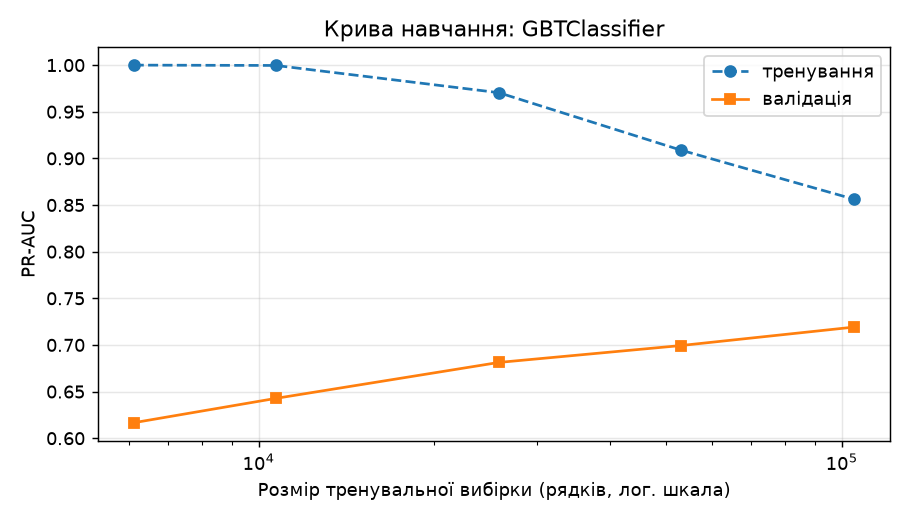

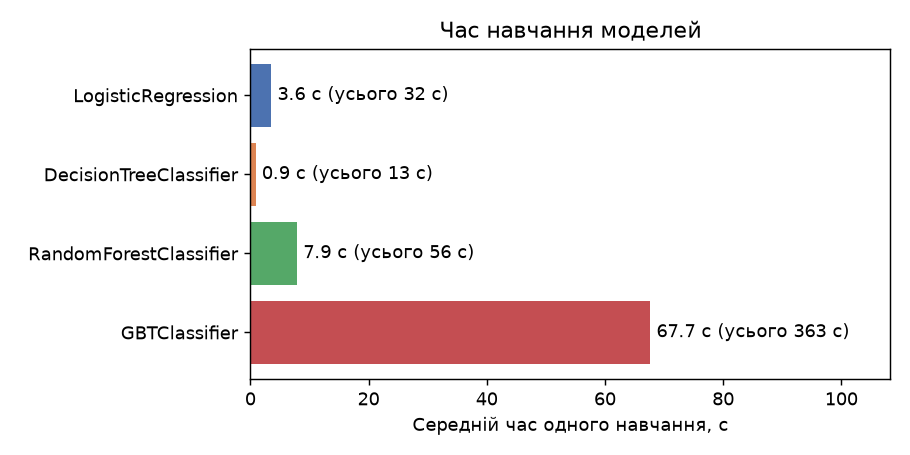

,train_fraction,train_rows,fit_seconds,train_accuracy,train_precision,train_recall,train_f1,train_macro_f1,train_weighted_f1,train_tp,train_fp,train_tn,train_fn,train_roc_auc,train_pr_auc,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_weighted_f1,val_tp,val_fp,val_tn,val_fn,val_roc_auc,val_pr_auc
0,0.057143,6109,47.70,0.999836,0.999179,1.000000,0.999589,0.999744,0.999836,1217.0,1.0,4891.0,0.0,0.999997,0.999986,0.831553,0.587081,0.523135,0.553266,0.724737,0.827829,2363.0,1662.0,16475.0,2154.0,0.801369,0.616613
1,0.100000,10703,50.74,0.994768,0.976337,0.999103,0.987589,0.992137,0.994790,2228.0,54.0,8419.0,2.0,0.999912,0.999629,0.830008,0.573836,0.572947,0.573391,0.733624,0.829958,2588.0,1922.0,16215.0,1929.0,0.818810,0.642700
2,0.242857,25825,59.65,0.950862,0.833501,0.948089,0.887110,0.927853,0.952002,4986.0,996.0,19570.0,273.0,0.991249,0.970440,0.827845,0.559683,0.640469,0.597357,0.743937,0.832064,2893.0,2276.0,15861.0,1624.0,0.839100,0.681244
3,0.500000,52930,72.61,0.910845,0.727630,0.903775,0.806193,0.874150,0.914220,9815.0,3674.0,38396.0,1045.0,0.969559,0.908971,0.823607,0.545758,0.687846,0.608619,0.747383,0.830811,3107.0,2586.0,15551.0,1410.0,0.850384,0.699313
4,1.000000,105191,91.65,0.880351,0.658816,0.861529,0.746659,0.834170,0.885862,18547.0,9605.0,74058.0,2981.0,0.948380,0.856075,0.822857,0.542640,0.709985,0.615134,0.750043,0.831152,3207.0,2703.0,15434.0,1310.0,0.861614,0.719184


In [13]:
for path in [
    plots.convergence(classification, FIG / "cls_linear_convergence.png"),
    plots.regularization_path(classification, "pr_auc", FIG / "cls_linear_regularization.png"),
    plots.tree_depth_curve(classification, "pr_auc", FIG / "cls_tree_depth.png"),
    plots.forest_curves(classification, "pr_auc", FIG / "cls_forest.png"),
    plots.gbt_iterations(classification, FIG / "cls_gbt_iterations.png"),
    plots.learning_curve(classification, "pr_auc", FIG / "cls_learning_curve.png"),
    plots.fit_times(classification, FIG / "cls_fit_times.png"),
]:
    show(path)
display(cls_tables["learning_curve"])

### 4.3 Якість моделей: Accuracy, Precision, Recall, F1 (клас «закритий», тест)

,model,accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,f1_95ci,pr_auc_95ci,fit_seconds,best_params
0,Baseline: majority (all open),0.795431,0.000000,0.000000,0.000000,0.443031,0.704801,NaN,NaN,NaN,NaN,NaN,NaN
1,LogisticRegression,0.755700,0.440320,0.716489,0.545440,0.689202,0.774145,0.817806,0.624417,[0.535; 0.557],[0.610; 0.638],3.4,"{""regParam"": 0.0005, ""elasticNetParam"": 0.0}"
2,DecisionTreeClassifier,0.746589,0.424633,0.672605,0.520599,0.674187,0.764937,0.794490,0.602374,[0.510; 0.531],[0.587; 0.615],1.6,"{""maxDepth"": 15, ""minInstancesPerNode"": 20}"
3,RandomForestClassifier,0.836318,0.596883,0.615685,0.606138,0.751416,0.837255,0.846299,0.683832,[0.593; 0.617],[0.671; 0.696],16.5,"{""numTrees"": 60, ""maxDepth"": 15}"
4,GBTClassifier,0.819697,0.545775,0.707148,0.616069,0.749126,0.827745,0.861732,0.718769,[0.605; 0.627],[0.707; 0.730],91.1,"{""maxDepth"": 7, ""stepSize"": 0.1, ""maxIter"": 198}"


,model,train_f1,val_f1,test_f1,train_pr_auc,val_pr_auc,test_pr_auc
0,LogisticRegression,0.542176,0.545637,0.545440,0.618100,0.624379,0.624417
1,DecisionTreeClassifier,0.620913,0.522656,0.520599,0.687097,0.605473,0.602374
2,RandomForestClassifier,0.738613,0.605093,0.606138,0.831191,0.681812,0.683832
3,GBTClassifier,0.746659,0.615134,0.616069,0.856075,0.719184,0.718769


Paired bootstrap, top-2 models: {'a': 'GBTClassifier', 'b': 'RandomForestClassifier', 'metric': 'pr_auc', 'diff': 0.034936059518483886, 'ci_low': 0.028515594789272226, 'ci_high': 0.04214210614359988, 'share_a_better': 1.0}


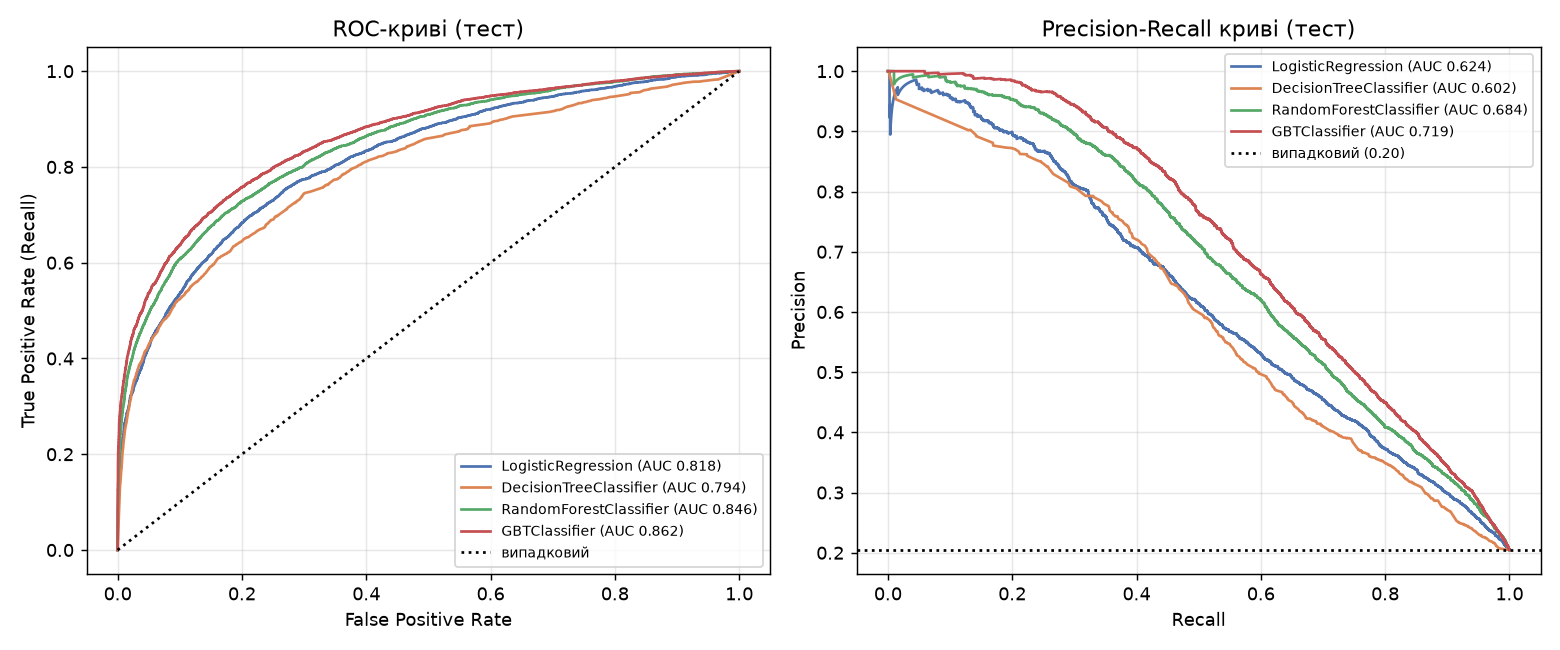

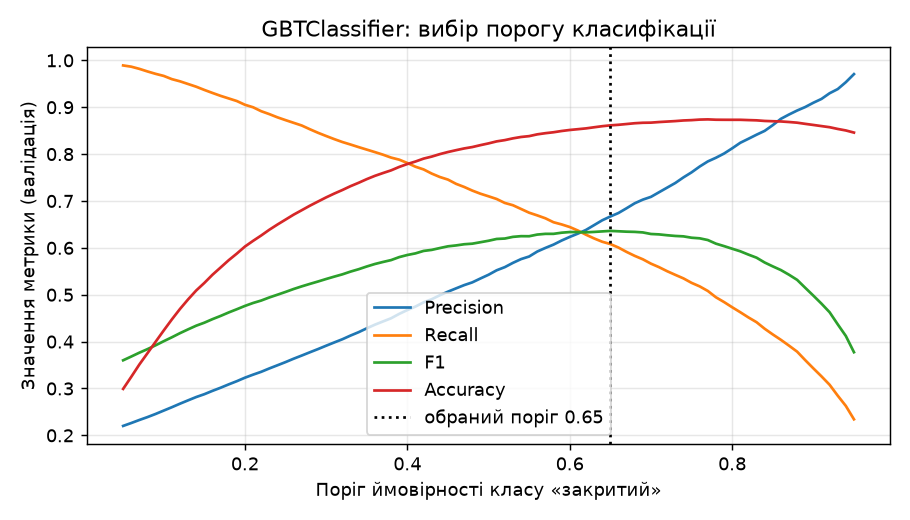

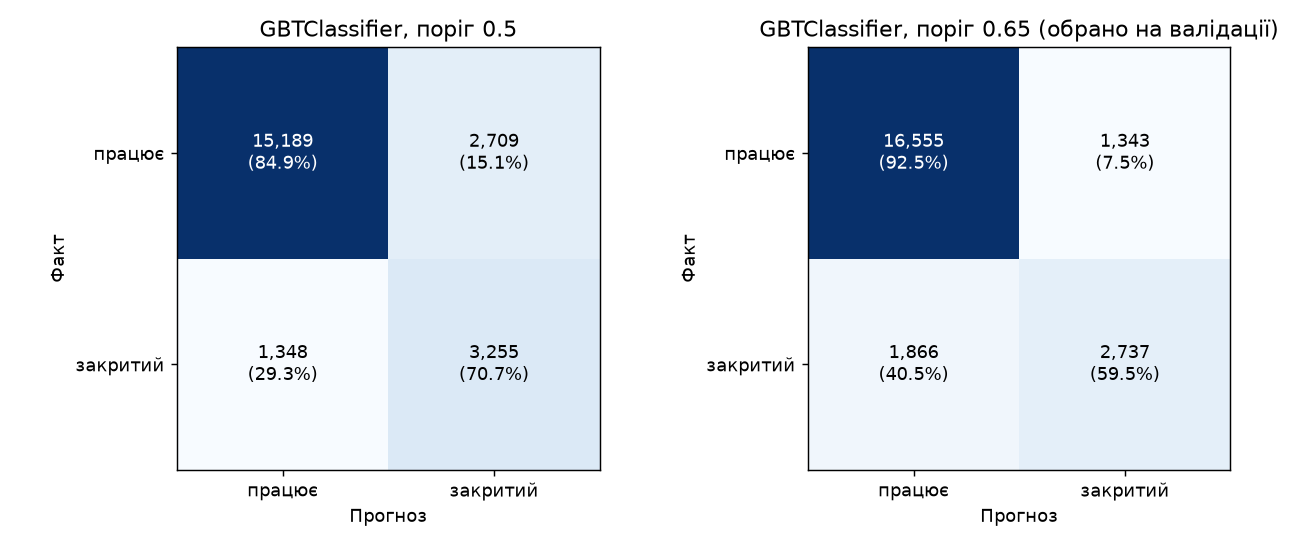

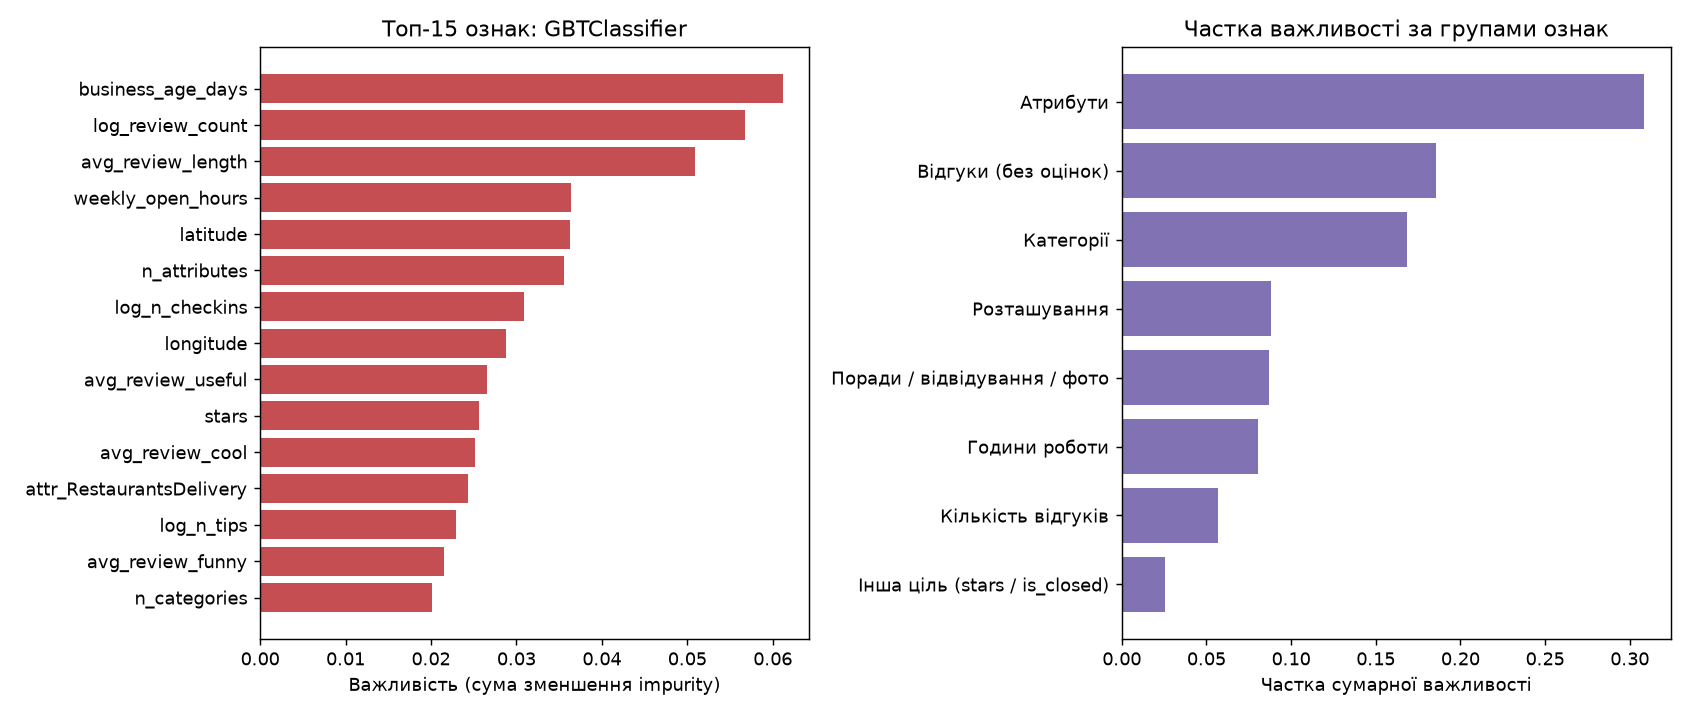

Threshold chosen on validation: {'threshold': 0.65, 'test_at_0.5': {'accuracy': 0.8196969023598951, 'precision': 0.545774647887324, 'recall': 0.7071475124918531, 'f1': 0.61606889372575, 'macro_f1': 0.7491263591614086, 'weighted_f1': 0.8277450429073344}, 'test_at_tuned': {'accuracy': 0.8573841162614995, 'precision': 0.6708333333333333, 'recall': 0.5946122094286335, 'f1': 0.6304272716802948, 'macro_f1': 0.7710356573715772, 'weighted_f1': 0.8541158977060335}}


,class_weights,threshold,threshold_kind,accuracy,precision,recall,f1,macro_f1,weighted_f1,pr_auc
0,weighted,0.50,0.5,0.819697,0.545775,0.707148,0.616069,0.749126,0.827745,0.718769
1,weighted,0.65,tuned,0.857384,0.670833,0.594612,0.630427,0.771036,0.854116,0.718769
2,unweighted,0.50,0.5,0.866761,0.790656,0.474256,0.592884,0.756615,0.853358,0.713881
3,unweighted,0.33,tuned,0.857117,0.669103,0.596567,0.630757,0.771089,0.854005,0.713881


In [14]:
display(cls_tables["comparison"])
display(cls_tables["generalisation"])
print("Paired bootstrap, top-2 models:", classification.extras["top_two"])
for path in [
    plots.roc_pr_curves(classification, FIG / "cls_roc_pr.png"),
    plots.threshold_curve(classification, FIG / "cls_threshold.png"),
    plots.confusion_matrices(classification, FIG / "cls_confusion.png"),
    plots.feature_importance(classification, FIG / "cls_feature_importance.png"),
]:
    show(path)
print("Threshold chosen on validation:", classification.extras["threshold"])
display(cls_tables["class_weights"])
release(classification.data)

### 4.4 Варіант з ознаками давності активності

Ті самі 4 алгоритми з гіперпараметрами, обраними в 4.1 (GBT заново обирає кількість ітерацій),
плюс базове правило «закритий, якщо останній відгук старший за N днів» (N обрано на validation).

[14:28:24] Task classification_recency: preparing data


[14:28:32] Task classification_recency: 167 features, train/val/test = 105191/22654/22501


[14:28:32] Task classification_recency: tuning LogisticRegression (1 settings)


[14:28:36]   LogisticRegression {'regParam': 0.0005, 'elasticNetParam': 0.0} fit 2.8s train pr_auc=0.8705 val pr_auc=0.8728


[14:28:41]   -> best LogisticRegression {'regParam': 0.0005, 'elasticNetParam': 0.0}: val pr_auc=0.8728, test pr_auc=0.8724


...

[14:29:22] Task classification_recency: tuning GBTClassifier (1 settings)


[14:31:10]   GBTClassifier {'maxDepth': 7, 'stepSize': 0.1, 'maxIter': 200} fit 100.5s train pr_auc=0.9677 val pr_auc=0.9141


[14:31:17]   -> best GBTClassifier {'maxDepth': 7, 'stepSize': 0.1, 'maxIter': 200}: val pr_auc=0.9141, test pr_auc=0.9149


,model,accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,f1_95ci,pr_auc_95ci,fit_seconds,best_params
0,Baseline: majority (all open),0.795431,0.000000,0.000000,0.000000,0.443031,0.704801,NaN,NaN,NaN,NaN,NaN,NaN
1,Baseline: days since last review >= 1007,0.880139,0.703545,0.715620,0.709532,0.817011,0.880516,NaN,NaN,NaN,NaN,NaN,NaN
2,LogisticRegression,0.897382,0.704895,0.857267,0.773650,0.853650,0.900920,0.946963,0.872433,[0.765; 0.783],[0.865; 0.880],2.8,"{""regParam"": 0.0005, ""elasticNetParam"": 0.0}"
3,DecisionTreeClassifier,0.887649,0.674399,0.871605,0.760425,0.843521,0.892620,0.950324,0.876893,[0.752; 0.771],[0.869; 0.885],1.4,"{""maxDepth"": 15, ""minInstancesPerNode"": 20}"
4,RandomForestClassifier,0.909115,0.736940,0.864219,0.795520,0.868547,0.911695,0.959891,0.901379,[0.787; 0.804],[0.896; 0.908],13.8,"{""numTrees"": 60, ""maxDepth"": 15}"
5,GBTClassifier,0.916537,0.757805,0.870085,0.810073,0.878295,0.918605,0.965033,0.914946,[0.802; 0.819],[0.909; 0.921],100.5,"{""maxDepth"": 7, ""stepSize"": 0.1, ""maxIter"": 200}"


,model,train_f1,val_f1,test_f1,train_pr_auc,val_pr_auc,test_pr_auc
0,LogisticRegression,0.775914,0.775989,0.773650,0.870464,0.872830,0.872433
1,DecisionTreeClassifier,0.813162,0.760471,0.760425,0.900794,0.877049,0.876893
2,RandomForestClassifier,0.852304,0.797279,0.795520,0.953031,0.900291,0.901379
3,GBTClassifier,0.887403,0.809504,0.810073,0.967695,0.914068,0.914946


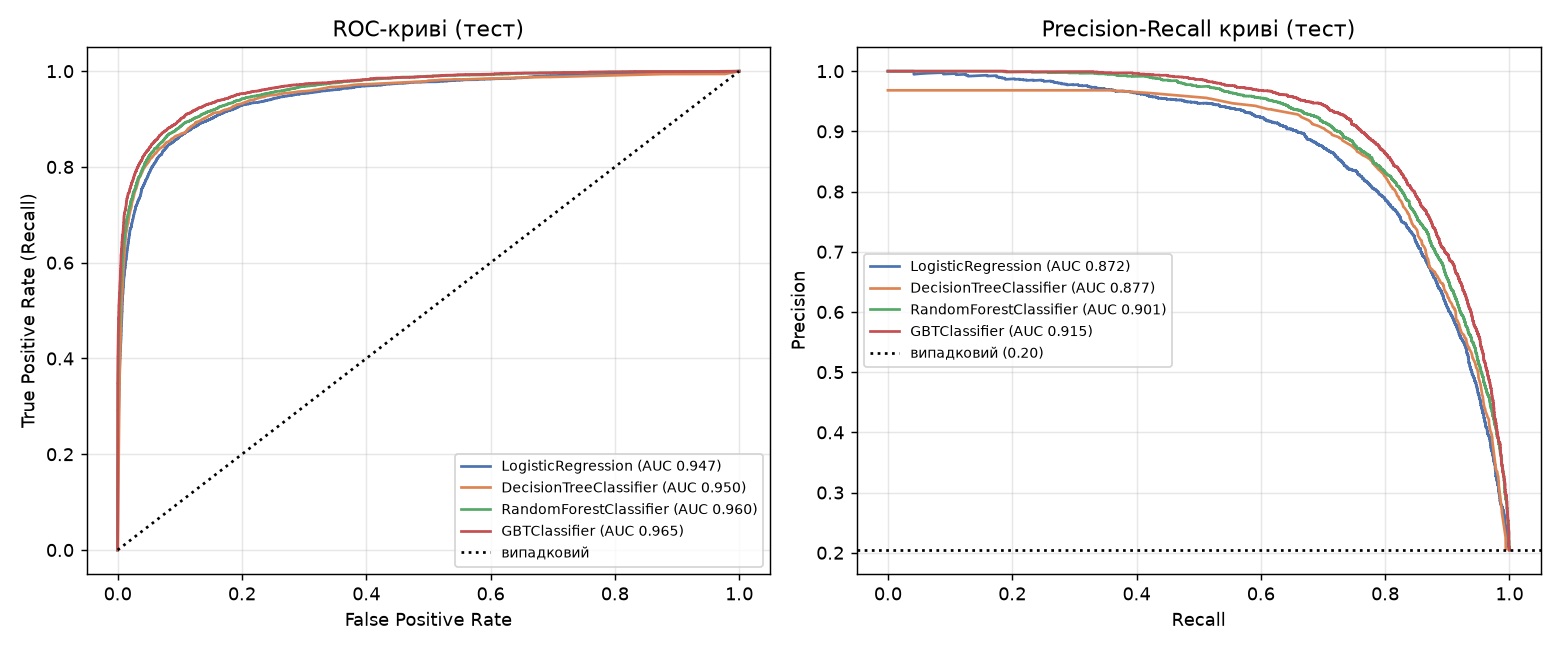

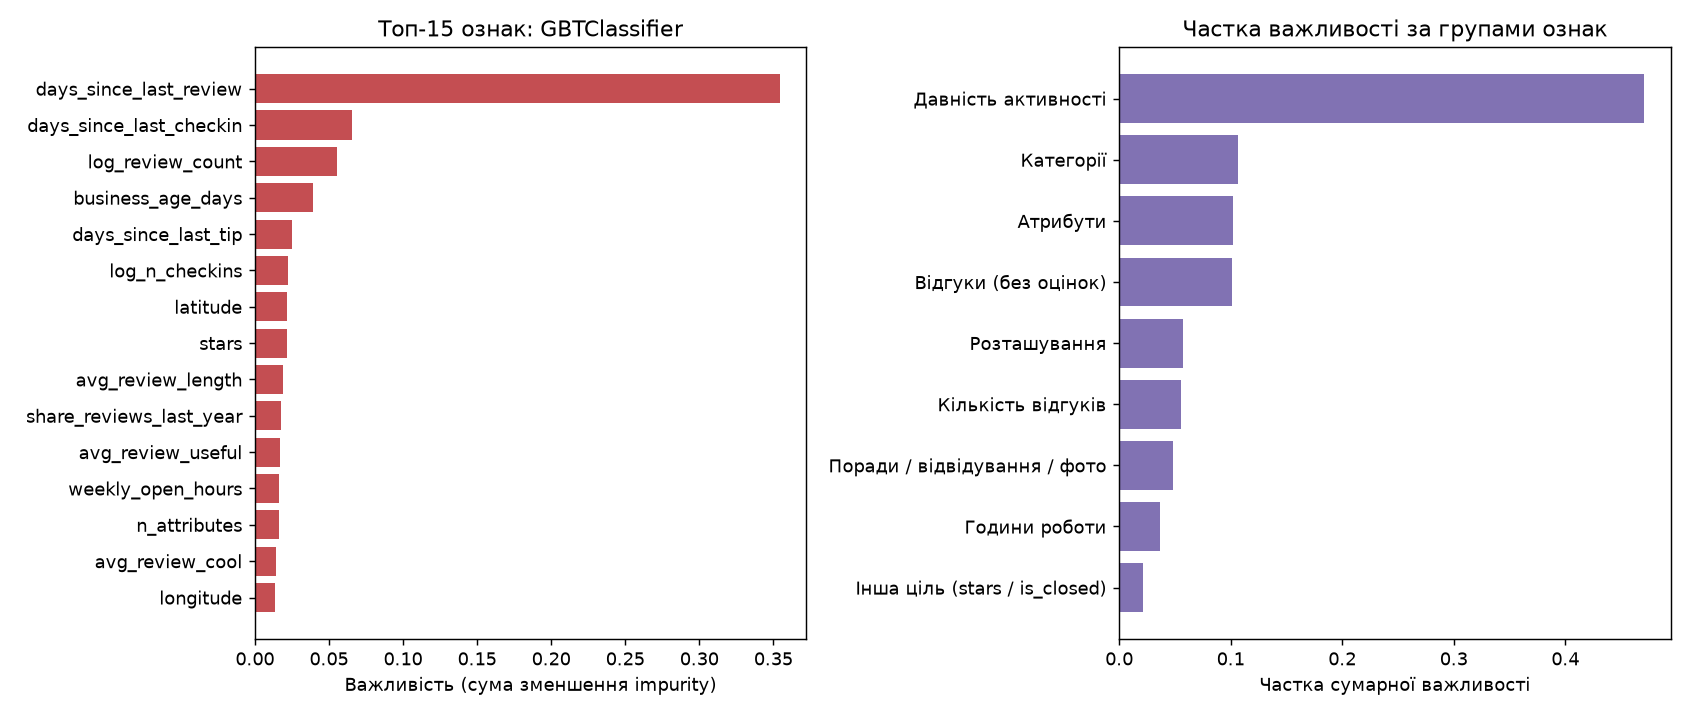

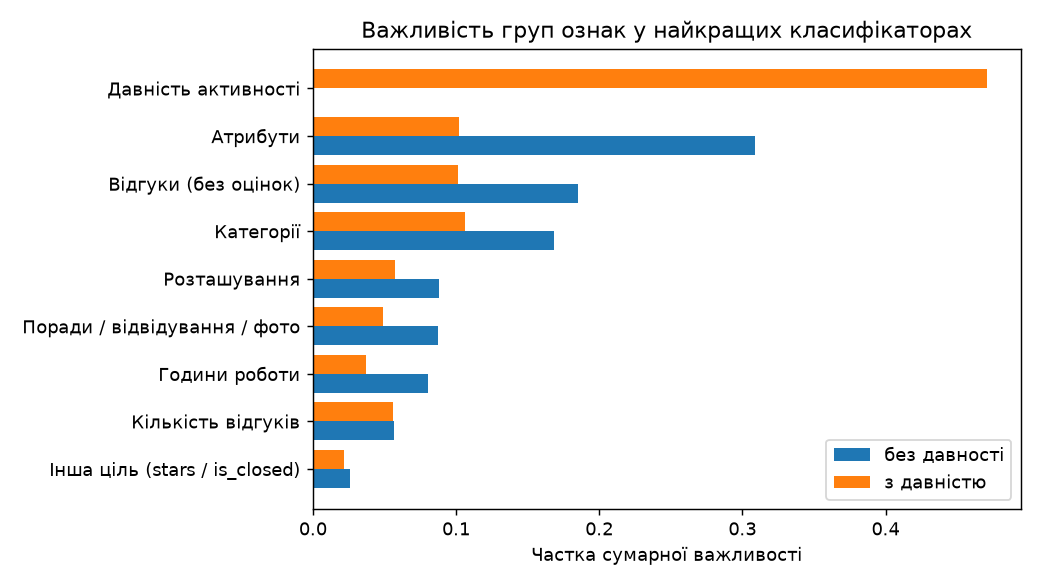

In [15]:
classification_recency = run_classification(
    features, include_recency=True, reuse_params_from=classification
)
rec_tables = report.write_task(classification_recency, TABLES)
display(rec_tables["comparison"])
display(rec_tables["generalisation"])
for path in [
    plots.roc_pr_curves(classification_recency, FIG / "cls_recency_roc_pr.png"),
    plots.feature_importance(classification_recency, FIG / "cls_recency_feature_importance.png"),
    plots.group_importance_comparison(
        [classification, classification_recency],
        ["без давності", "з давністю"],
        FIG / "cls_group_importance.png",
    ),
]:
    show(path)
release(classification_recency.data)

## 5. Порівняння алгоритмів

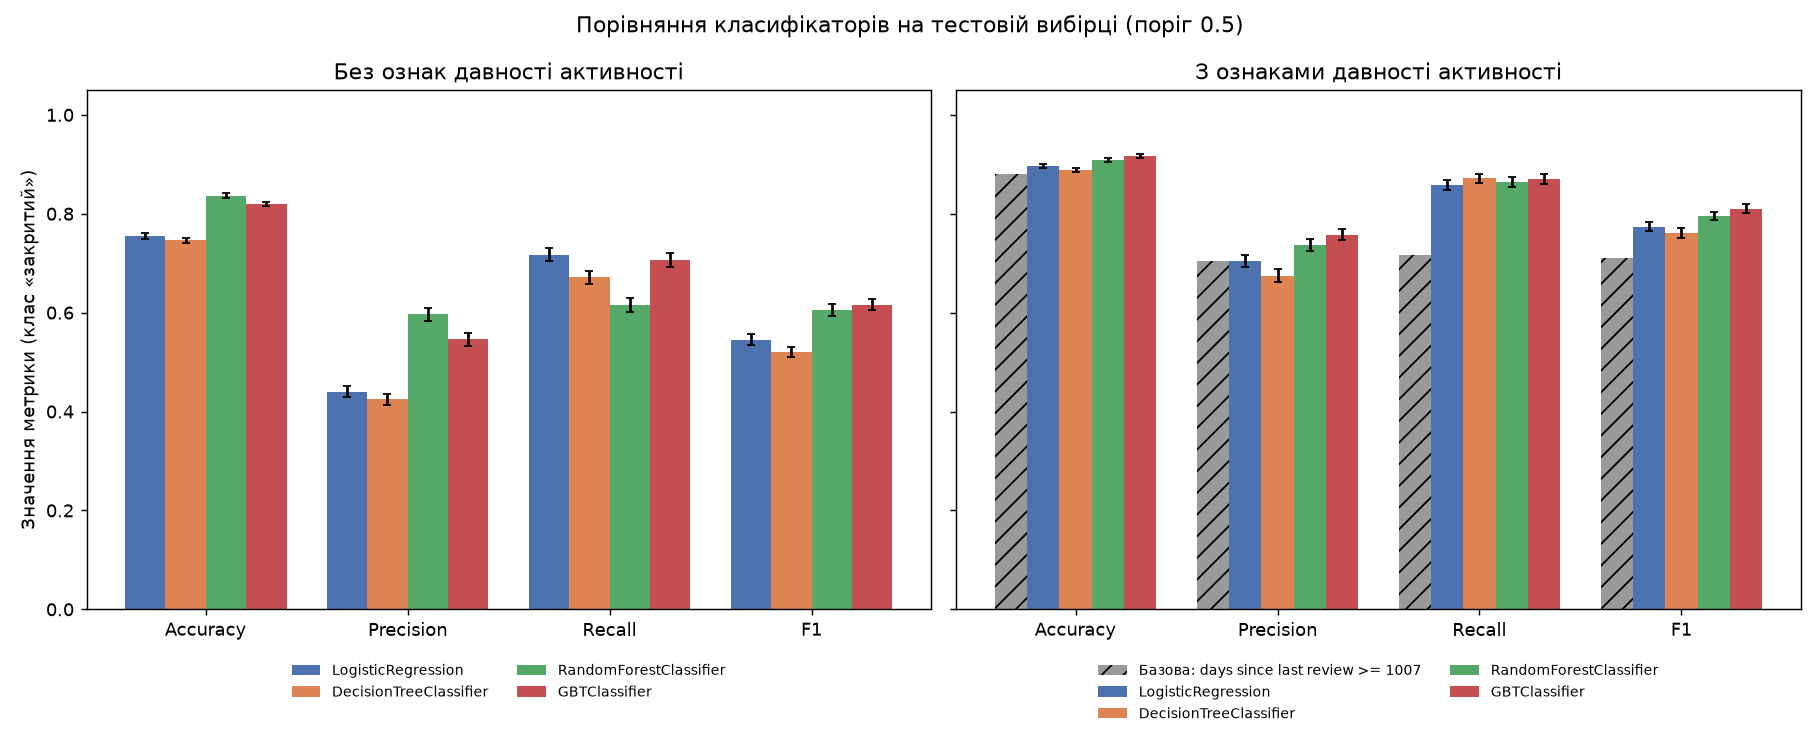

,task,model,RMSE,R2,fit_s,selected,Accuracy,Precision,Recall,F1,PR-AUC
0,regression,LinearRegression,0.775721,0.364320,4.4,False,NaN,NaN,NaN,NaN,NaN
1,regression,DecisionTreeRegressor,0.788463,0.343265,1.0,False,NaN,NaN,NaN,NaN,NaN
2,regression,RandomForestRegressor,0.721801,0.449620,84.8,False,NaN,NaN,NaN,NaN,NaN
3,regression,GBTRegressor,0.685968,0.502910,68.4,True,NaN,NaN,NaN,NaN,NaN
4,classification,LogisticRegression,NaN,NaN,3.4,False,0.755700,0.440320,0.716489,0.545440,0.624417
5,classification,DecisionTreeClassifier,NaN,NaN,1.6,False,0.746589,0.424633,0.672605,0.520599,0.602374
6,classification,RandomForestClassifier,NaN,NaN,16.5,False,0.836318,0.596883,0.615685,0.606138,0.683832
7,classification,GBTClassifier,NaN,NaN,91.1,True,0.819697,0.545775,0.707148,0.616069,0.718769
8,classification_recency,LogisticRegression,NaN,NaN,2.8,False,0.897382,0.704895,0.857267,0.773650,0.872433
9,classification_recency,DecisionTreeClassifier,NaN,NaN,1.4,False,0.887649,0.674399,0.871605,0.760425,0.876893


Total runtime: 37.2 min


In [16]:
show(plots.classification_comparison(
    [classification, classification_recency],
    ["Без ознак давності активності", "З ознаками давності активності"],
    FIG / "cls_comparison.png",
))

results = [regression, classification, classification_recency]
tables = {r.task.name: report.write_task(r, TABLES) for r in results}
stages = "\n".join(f"{i}. {s}" for i, s in enumerate(regression.data.preprocessing.stages, 1))
report.write_digest(results, tables, ML_REPORT_DIR / "results.md", stages)

summary = report.summary(results)
summary["runtime_minutes"] = (time.perf_counter() - started) / 60
ML_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
import json
(ML_RESULTS_DIR / "summary.json").write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")

overview = []
for r in results:
    for fam in r.families:
        m = fam.test_metrics
        overview.append({
            "task": r.task.name,
            "model": fam.spec.name,
            **({"RMSE": m["rmse"], "R2": m["r2"]} if r.task.label == "stars"
               else {"Accuracy": m["accuracy"], "Precision": m["precision"],
                     "Recall": m["recall"], "F1": m["f1"], "PR-AUC": m["pr_auc"]}),
            "fit_s": round(fam.fit_seconds, 1),
            "selected": fam is r.best,
        })
display(pd.DataFrame(overview))
print(f"Total runtime: {summary['runtime_minutes']:.1f} min")

## Висновки

* **Регресія `stars`:** найкращий `GBTRegressor` — RMSE 0,686, R² 0,503 на тесті (база «середнє»: RMSE 0,973);
  далі RandomForest (0,722 / 0,450), LinearRegression (0,776 / 0,364), DecisionTree (0,788 / 0,343).
  Без характеристик відгуків (лише профіль бізнесу) GBT досягає R² 0,342.
* **Класифікація `is_closed` без ознак давності:** найкращий `GBTClassifier` — Accuracy 0,820, Precision 0,546,
  Recall 0,707, F1 0,616, PR-AUC 0,719; RandomForest — найвищі Accuracy 0,836 і Precision 0,597 (F1 0,606);
  LogisticRegression F1 0,545; DecisionTree F1 0,521. Модель «усі працюють» має Accuracy 0,795, але F1 = 0.
* **З ознаками давності активності** F1 зростає до 0,810 (GBT), а одне правило «немає відгуків ≥ 1007 днів» дає 0,710 —
  ці ознаки є переважно наслідком закриття.
* Ансамблі дерев (бустинг і ліс) перевершують лінійні моделі та одиночне дерево в обох задачах; одиночне дерево
  найбільше схильне до перенавчання, лінійні моделі — до недонавчання. Бустинг найточніший, але навчається найдовше.

Детальний аналіз, обмеження та всі таблиці — у [`src/reports/ml/README.md`](../reports/ml/README.md).

In [17]:
spark.stop()